# Práctica 2 - Ejercicio 1

Asignatura: Programación para la Inteligencia Artificial

Alumno: Francisco Javier Pérez Cazorla

Este es el primer ejercicio de la Práctica 2 de Programación para la Inteligencia Artificial.

El objetivo de este ejercicio es entrenar un modelo neuronal de clasificación usando solo neuronas lineales para el conjunto de datos CIFAR10. El conjunto está incluido en torchvision:

https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html

Dado el tamaño del conjunto de datos y los tiempos que puede tardar el entrenamiento, se requiere que el código permita elegir dispositivo de ejecución ('cpu' o 'cuda'). En el caso de elegir la opción de ejecución en GPU (y de haber una GPU disponible), el código deberá realizar el entrenamiento en GPU de manera eficiente.

Se usarán las herramientas pertinentes tanto para completar el código como para realizar experimentos de los que se puedan extraer conclusiones sobre la capacidad del modelo entrenado. En el cuaderno se incluye los experimentos más relevantes.

Como conjunto de test se usará el conjunto de test íntegro que provee el conjunto de datos.

Se incluirá una comparación de tiempos de entrenamiento en CPU y GPU.

# 2. Desarrollo y Metodología

## 2.1. Configuración Inicial

Importamos bibliotecas, conectamos con Drive y definimos la ruta de trabajo.

In [1]:
# --- Bibliotecas Fundamentales ---
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, utils
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np # Necesario para los ticks de las gráficas

# --- Bibliotecas de Utilidad y Visualización ---
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time

# --- Conexión con Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# Definimos una ruta de trabajo para esta versión del proyecto
directorio_proyecto = ('/content/drive/MyDrive/Colab/Practica2Ej1_VC')

print(f"-> Montado en Google Drive.")
print(f"-> Directorio de trabajo: {directorio_proyecto}")


Mounted at /content/drive
-> Montado en Google Drive.
-> Directorio de trabajo: /content/drive/MyDrive/Colab/Practica2Ej1_VC


## 2.2. Carga y Preparación de Datos (CIFAR-10)

Cargamos el dataset CIFAR-10.
* `transformacion_tensor`: Convierte imágenes a Tensores y normaliza a [0, 1].
* Dividimos el conjunto de prueba (10.000 imágenes) en 5.000 para validación (`datos_val_cpu`) y 5.000 para prueba final (`datos_test_cpu`).

In [2]:
# --- Transformación ---
transformacion_tensor = transforms.ToTensor()

# --- Carga de Datasets (en CPU) ---
datos_entrenamiento_cpu = datasets.CIFAR10(root=directorio_proyecto,
                                           train=True,
                                           download=True,
                                           transform=transformacion_tensor)

datos_test_completos_cpu = datasets.CIFAR10(root=directorio_proyecto,
                                            train=False,
                                            download=True,
                                            transform=transformacion_tensor)

print(f"\n[INFO] Imágenes de entrenamiento (base): {len(datos_entrenamiento_cpu)}")
print(f"[INFO] Imágenes de prueba (base):      {len(datos_test_completos_cpu)}")


# --- Función de División ---
def dividir_conjunto(dataset_base, proporcion_A=0.5):
    """
    Divide un dataset en dos subconjuntos (A y B) de forma aleatoria.
    Usa torch.randperm para una división robusta.
    """
    total_indices = len(dataset_base)
    indices_permutados = torch.randperm(total_indices)

    limite_division = int(total_indices * proporcion_A)

    indices_A = indices_permutados[:limite_division]
    indices_B = indices_permutados[limite_division:]

    subconjunto_A = Subset(dataset_base, indices_A)
    subconjunto_B = Subset(dataset_base, indices_B)

    return subconjunto_A, subconjunto_B

# Aplicamos la división
datos_val_cpu, datos_test_cpu = dividir_conjunto(datos_test_completos_cpu, 0.5)

print("=" * 40)
print("     ESTADO FINAL DE LOS DATOS (EN CPU)")
print("=" * 40)
print(f"| Entrenamiento | {len(datos_entrenamiento_cpu):>10} imágenes |")
print(f"| Validación    | {len(datos_val_cpu):>10} imágenes |")
print(f"| Prueba Final  | {len(datos_test_cpu):>10} imágenes |")
print("=" * 40)


100%|██████████| 170M/170M [00:03<00:00, 48.7MB/s]



[INFO] Imágenes de entrenamiento (base): 50000
[INFO] Imágenes de prueba (base):      10000
     ESTADO FINAL DE LOS DATOS (EN CPU)
| Entrenamiento |      50000 imágenes |
| Validación    |       5000 imágenes |
| Prueba Final  |       5000 imágenes |


## 2.3. Visualización de Muestra

Visualizamos una imagen para confirmar que la carga es correcta.
Usamos `.permute(1, 2, 0)` para cambiar el formato de `(Canal, Alto, Ancho)` a `(Alto, Ancho, Canal)`, que es el que `matplotlib` espera.


Forma del tensor de imagen: torch.Size([3, 32, 32])


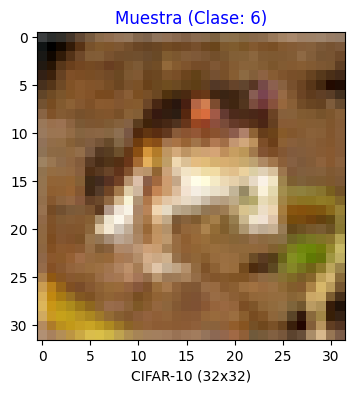

In [3]:
# --- Visualización de una Muestra ---
img_muestra, etiqueta_muestra = datos_entrenamiento_cpu[0]
print(f"\nForma del tensor de imagen: {img_muestra.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(img_muestra.permute(1, 2, 0))
plt.title(f"Muestra (Clase: {etiqueta_muestra})", color='blue')
plt.xlabel("CIFAR-10 (32x32)")
plt.grid(False)
plt.show()


## 3. Utilidades de Entrenamiento

En esta celda definimos todas las clases y funciones que nos ayudarán a entrenar los modelos.

* `MonitorPaciencia`: Clase para el Early Stopping.
* `DatasetPrecargadoGPU`: Clase para mover todo el dataset a la VRAM de la GPU y acelerar el entrenamiento.
* `ejecutar_ciclo_entrenamiento`: **Función unificada** que maneja el bucle de entrenamiento. Puede ejecutar un número fijo de épocas (para los tests de velocidad) o usar el `MonitorPaciencia` (para el modelo final).

In [5]:
class MonitorPaciencia():
  """
  Clase para implementar la lógica de detención temprana.
  Monitoriza la pérdida de validación y detiene el entrenamiento si
  no mejora (`diferencia_minima`) durante un número de épocas (`max_paciencia`).
  """
  def __init__(self, max_paciencia=5, diferencia_minima=0):
    self.max_paciencia = max_paciencia
    self.diferencia_minima = diferencia_minima
    self.mejor_perdida = None
    self.epocas_sin_mejora = 0
    self.parar_ahora = False

  def evaluar_mejoria(self, perdida_val_actual):
    """Comprueba si la pérdida actual es una mejora."""
    if self.mejor_perdida is None:
      self.mejor_perdida = perdida_val_actual
    elif (perdida_val_actual + self.diferencia_minima) < self.mejor_perdida:
      self.mejor_perdida = perdida_val_actual
      self.epocas_sin_mejora = 0
    else:
      self.epocas_sin_mejora += 1
      if self.epocas_sin_mejora >= self.max_paciencia:
        print(f"\n[ALERTA] Detención Temprana. No hay mejora en {self.max_paciencia} épocas.")
        self.parar_ahora = True


class DatasetPrecargadoGPU(Dataset):
    """
    Dataset que mueve todos los datos a un dispositivo GPU en la inicialización
    para eliminar el cuello de botella de transferencia CPU -> GPU en cada lote.
    """
    def __init__(self, dataset_cpu, dispositivo_gpu):
        self.dispositivo_gpu = dispositivo_gpu
        lista_imgs, lista_etqs = [], []

        print(f"+++ PRECARGANDO {len(dataset_cpu)} elementos en {dispositivo_gpu} +++")
        for i in tqdm(range(len(dataset_cpu))):
          imagen, etiqueta = dataset_cpu[i]
          lista_imgs.append(imagen)
          lista_etqs.append(etiqueta)

        self.datos_en_gpu = torch.stack(lista_imgs).to(dispositivo_gpu, non_blocking=True)
        self.etiquetas_en_gpu = torch.tensor(lista_etqs, device=dispositivo_gpu, dtype=torch.long)
        print(f"+++ Precarga en {dispositivo_gpu} completada. +++")

    def __len__(self):
      return len(self.datos_en_gpu)

    def __getitem__(self, idx):
      return self.datos_en_gpu[idx], self.etiquetas_en_gpu[idx]


def ejecutar_ciclo_entrenamiento(cargador_train, cargador_val, red, max_epocas, criterio, tasa_aprendizaje, clase_optimizador, frecuencia_val, monitor=None):
    """
    Bucle de entrenamiento UNIFICADO.
    - Si 'monitor' es None, ejecuta 'max_epocas' (para tests de velocidad).
    - Si 'monitor' es una instancia de MonitorPaciencia, activa el Early Stopping.
    """
    historial_perdida_ent = []
    historial_perdida_val = []
    historial_acc_val = []

    optimizador = clase_optimizador(red.parameters(), lr=tasa_aprendizaje)
    dispositivo_actual = next(red.parameters()).device

    barra_epocas = tqdm(range(max_epocas), desc="Época")

    for epoca in barra_epocas:

        # --- FASE DE ENTRENAMIENTO ---
        perdidas_lote_ent = []
        for imagenes_lote, etiquetas_lote in cargador_train:
            # Si no están precargados (CPU), los movemos
            if dispositivo_actual == torch.device('cpu'):
                imagenes_lote, etiquetas_lote = imagenes_lote.to(dispositivo_actual), etiquetas_lote.to(dispositivo_actual)

            predicciones = red(imagenes_lote)
            optimizador.zero_grad()
            perdida = criterio(predicciones, etiquetas_lote)
            perdida.backward()
            optimizador.step()
            perdidas_lote_ent.append(perdida.clone().detach())

        perdida_epoca_ent = torch.tensor(perdidas_lote_ent).mean().item()
        historial_perdida_ent.append(perdida_epoca_ent)
        barra_epocas.set_postfix(loss_train=f"{perdida_epoca_ent:.4f}")

        # --- FASE DE VALIDACIÓN ---
        if epoca % frecuencia_val == 0:
            perdidas_lote_val = []
            correctas_val_total = 0
            muestras_val_total = 0

            with torch.no_grad():
                for imagenes_val, etiquetas_val in cargador_val:
                    if dispositivo_actual == torch.device('cpu'):
                        imagenes_val, etiquetas_val = imagenes_val.to(dispositivo_actual), etiquetas_val.to(dispositivo_actual)

                    predicciones_val = red(imagenes_val)
                    perdida_val = criterio(predicciones_val, etiquetas_val)
                    perdidas_lote_val.append(perdida_val.clone().detach())

                    correctas = torch.sum(etiquetas_val == torch.argmax(predicciones_val, dim=-1)).item()
                    correctas_val_total += correctas
                    muestras_val_total += etiquetas_val.size(0)

            perdida_epoca_val = torch.tensor(perdidas_lote_val).mean().item()
            acc_epoca_val = correctas_val_total / muestras_val_total

            historial_perdida_val.append(perdida_epoca_val)
            historial_acc_val.append(acc_epoca_val)

            # --- Lógica de Early Stopping ---
            if monitor is not None:
                monitor.evaluar_mejoria(perdida_epoca_val)
                if monitor.parar_ahora:
                    print("-> Entrenamiento detenido por MonitorPaciencia.")
                    break

    return red, historial_perdida_ent, historial_perdida_val, historial_acc_val


## 4. Experimento 1: Comparativa de Velocidad (CPU vs. GPU)

Primero, realizamos una comparativa de velocidad. Entrenamos un modelo en CPU y otro en GPU por un número fijo y reducido de épocas (`EPOCAS_TEST_VELOCIDAD = 20`) para medir la ganancia de eficiencia.

Usamos la función `ejecutar_ciclo_entrenamiento` sin un monitor.

In [11]:
# === Celda 12: Experimento 1: Comparativa de Velocidad (CPU vs. GPU) ===

# --- Configuración del Experimento 1 ---
CFG_LOTE_SIZE = 512
CFG_LR = 1e-3
EPOCAS_TEST_VELOCIDAD = 20 # Número reducido de épocas solo para el test
CFG_FREC_VAL = 5

funcion_costo = torch.nn.CrossEntropyLoss()
clase_optimizador = torch.optim.Adam

# --- Arquitectura del Modelo (Versión B) ---
neuronas_ocultas = 128
neuronas_salida = 10
dimension_entrada = 3*32*32

# --- 1. PRUEBA EN CPU ---
dispositivo_exp1 = 'cpu'
print(f"||| INICIO TEST VELOCIDAD: CPU |||")

cargador_ent_cpu = DataLoader(datos_entrenamiento_cpu, batch_size=CFG_LOTE_SIZE, shuffle=True)
cargador_val_cpu = DataLoader(datos_val_cpu, batch_size=CFG_LOTE_SIZE, shuffle=True)

red_cpu = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(dimension_entrada, neuronas_ocultas),
    torch.nn.Linear(neuronas_ocultas, neuronas_salida)
).to(dispositivo_exp1)

inicio_cpu = time.time()

# Guardamos los historiales
red_cpu, hist_loss_ent_cpu, hist_loss_val_cpu, hist_acc_val_cpu = ejecutar_ciclo_entrenamiento(
    cargador_ent_cpu, cargador_val_cpu, red_cpu,
    EPOCAS_TEST_VELOCIDAD, funcion_costo, CFG_LR,
    clase_optimizador, CFG_FREC_VAL, monitor=None
)
# ===========================

fin_cpu = time.time()
tiempo_cpu = fin_cpu - inicio_cpu
print(f"\n*** Test en CPU finalizado. Duración: {tiempo_cpu:.2f} seg. ***")


# --- 2. PRUEBA EN GPU ---
dispositivo_exp2 = 'cuda'
print(f"\n||| INICIO TEST VELOCIDAD: GPU (Eficiente) |||")

datos_ent_gpu = DatasetPrecargadoGPU(datos_entrenamiento_cpu, dispositivo_gpu=dispositivo_exp2)
datos_val_gpu = DatasetPrecargadoGPU(datos_val_cpu, dispositivo_gpu=dispositivo_exp2)

cargador_ent_gpu = DataLoader(datos_ent_gpu, batch_size=CFG_LOTE_SIZE, shuffle=True)
cargador_val_gpu = DataLoader(datos_val_gpu, batch_size=CFG_LOTE_SIZE, shuffle=True)

red_gpu = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(dimension_entrada, neuronas_ocultas),
    torch.nn.Linear(neuronas_ocultas, neuronas_salida)
).to(dispositivo_exp2)

inicio_gpu = time.time()

# Guardamos los historiales
red_gpu, hist_loss_ent_gpu, hist_loss_val_gpu, hist_acc_val_gpu = ejecutar_ciclo_entrenamiento(
    cargador_ent_gpu, cargador_val_gpu, red_gpu,
    EPOCAS_TEST_VELOCIDAD, funcion_costo, CFG_LR,
    clase_optimizador, CFG_FREC_VAL, monitor=None
)
# ===========================

fin_gpu = time.time()
tiempo_gpu = fin_gpu - inicio_gpu
print(f"\n*** Test en GPU finalizado. Duración: {tiempo_gpu:.2f} seg. ***")


||| INICIO TEST VELOCIDAD: CPU |||


Época: 100%|██████████| 20/20 [02:55<00:00,  8.75s/it, loss_train=1.7051]



*** Test en CPU finalizado. Duración: 175.03 seg. ***

||| INICIO TEST VELOCIDAD: GPU (Eficiente) |||
+++ PRECARGANDO 50000 elementos en cuda +++


100%|██████████| 50000/50000 [00:07<00:00, 6623.20it/s]


+++ Precarga en cuda completada. +++
+++ PRECARGANDO 5000 elementos en cuda +++


100%|██████████| 5000/5000 [00:00<00:00, 7984.00it/s]


+++ Precarga en cuda completada. +++


Época: 100%|██████████| 20/20 [00:11<00:00,  1.70it/s, loss_train=1.7038]


*** Test en GPU finalizado. Duración: 11.75 seg. ***


--- Visualización: Curvas de Aprendizaje (CPU) ---


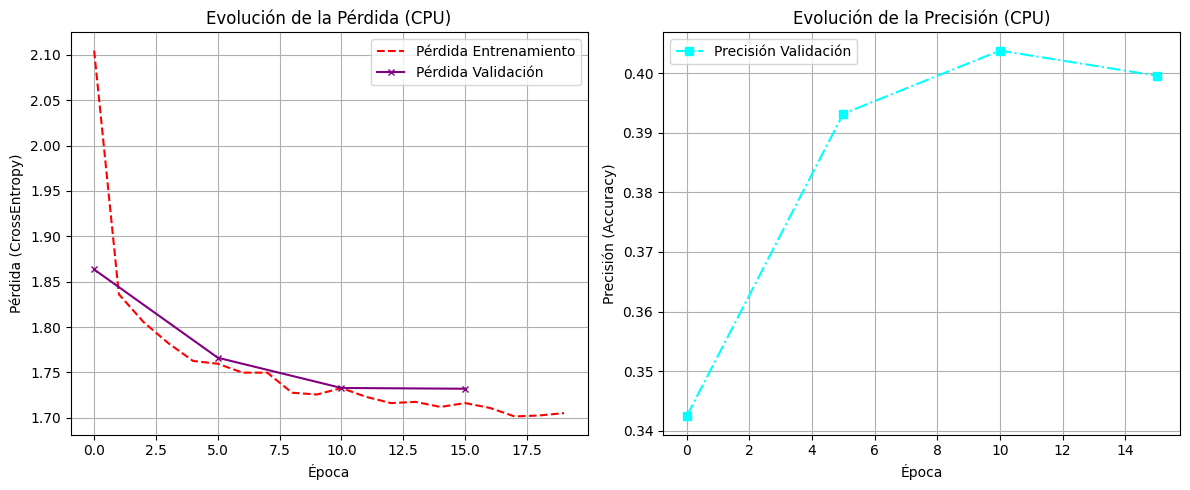

In [12]:
# === Celda 12.1: Gráficas de Resultados (CPU) ===

print("--- Visualización: Curvas de Aprendizaje (CPU) ---")
plt.figure(figsize=(12, 5))

# --- Gráfico de Pérdida ---
plt.subplot(1, 2, 1)
plt.plot(hist_loss_ent_cpu, label="Pérdida Entrenamiento", color="red", linestyle="--")
eje_x_val_cpu = range(0, CFG_FREC_VAL * len(hist_loss_val_cpu), CFG_FREC_VAL)
plt.plot(eje_x_val_cpu, hist_loss_val_cpu, label="Pérdida Validación", color="purple", marker="x", markersize=5)
plt.title("Evolución de la Pérdida (CPU)")
plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.legend()
plt.grid(True)

# --- Gráfico de Precisión  ---
plt.subplot(1, 2, 2)
plt.plot(eje_x_val_cpu, hist_acc_val_cpu, label="Precisión Validación", color="cyan", marker="s", linestyle="-.")
plt.title("Evolución de la Precisión (CPU)")
plt.xlabel("Época")
plt.ylabel("Precisión (Accuracy)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

-> Predicciones (CPU) generadas. Forma: torch.Size([5000])
--- Visualización: Matriz de Confusión (CPU) ---


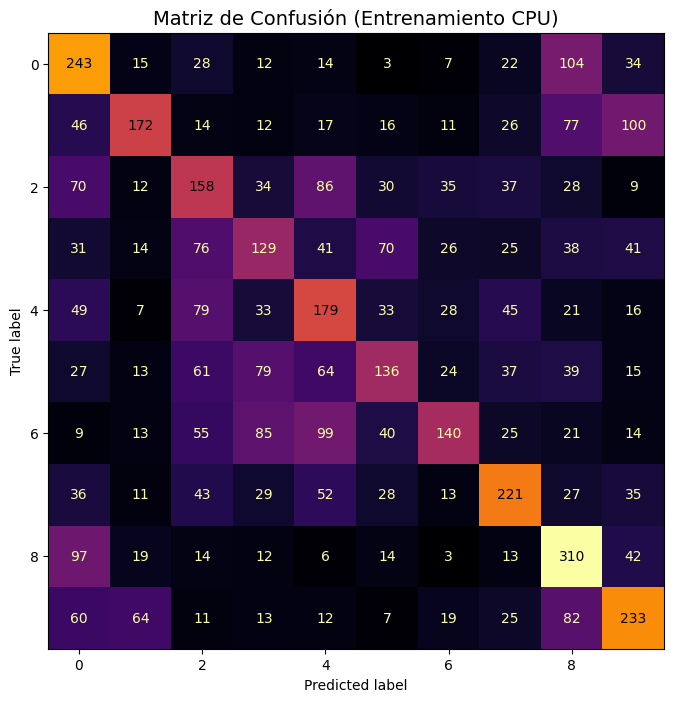

In [13]:
# === Celda 12.2: Matriz de Confusión (CPU) ===

cargador_test_cpu = DataLoader(datos_test_cpu, batch_size=CFG_LOTE_SIZE, shuffle=False)
lista_preds_cpu = []
lista_reales_cpu = []

with torch.no_grad():
  for imagenes_lote_test, etiquetas_lote_test in cargador_test_cpu:
    imagenes_lote_test = imagenes_lote_test.to(dispositivo_exp1)
    lista_reales_cpu.append(etiquetas_lote_test)
    lista_preds_cpu.append(red_cpu(imagenes_lote_test).detach())

etiquetas_reales_tensor_cpu = torch.cat(lista_reales_cpu)
predicciones_tensor_cpu = torch.argmax(torch.cat(lista_preds_cpu), dim=-1)

print(f"-> Predicciones (CPU) generadas. Forma: {predicciones_tensor_cpu.shape}")
matriz_conf_cpu = confusion_matrix(etiquetas_reales_tensor_cpu.cpu(), predicciones_tensor_cpu.cpu())

# --- Visualización de la Matriz ---
print("--- Visualización: Matriz de Confusión (CPU) ---")
fig, ax = plt.subplots(figsize=(8, 8))
disp_cpu = ConfusionMatrixDisplay(matriz_conf_cpu, display_labels=[str(i) for i in range(10)])

disp_cpu.plot(cmap='inferno', ax=ax, colorbar=False)
ticks_personalizados = np.arange(0, 10, 2)
ax.set_xticks(ticks_personalizados)
ax.set_yticks(ticks_personalizados)
ax.set_xticklabels(ticks_personalizados)
ax.set_yticklabels(ticks_personalizados)
ax.set_title("Matriz de Confusión (Entrenamiento CPU)", fontsize=14)
ax.grid(False)
plt.show()

--- Visualización: Curvas de Aprendizaje (GPU) ---


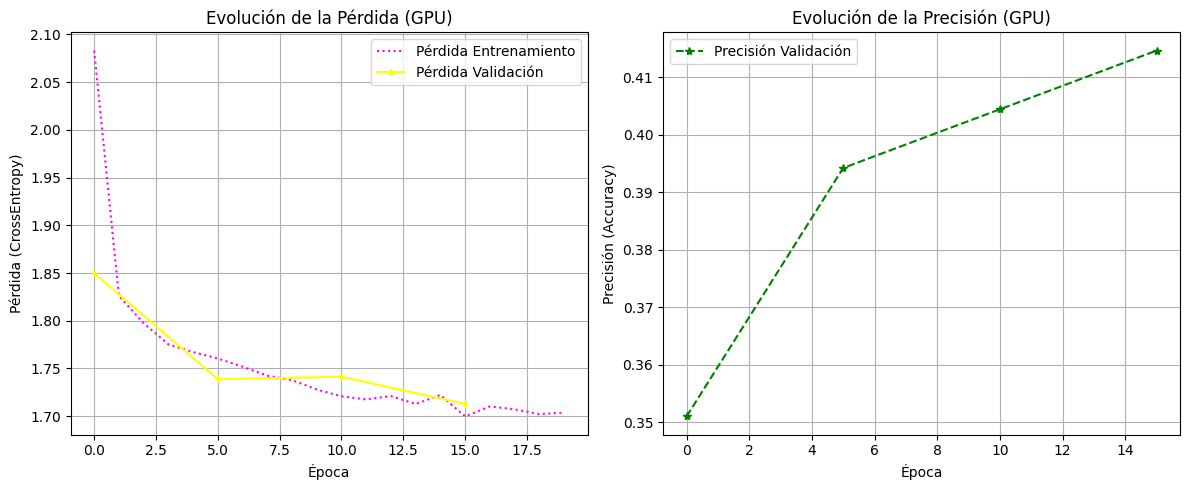

In [14]:
# === Celda 12.3: Gráficas de Resultados (GPU) ===

print("--- Visualización: Curvas de Aprendizaje (GPU) ---")
plt.figure(figsize=(12, 5))

# --- Gráfico de Pérdida ---
plt.subplot(1, 2, 1)
plt.plot(hist_loss_ent_gpu, label="Pérdida Entrenamiento", color="magenta", linestyle=":")
eje_x_val_gpu = range(0, CFG_FREC_VAL * len(hist_loss_val_gpu), CFG_FREC_VAL)
plt.plot(eje_x_val_gpu, hist_loss_val_gpu, label="Pérdida Validación", color="yellow", marker="d", markersize=3)
plt.title("Evolución de la Pérdida (GPU)")
plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.legend()
plt.grid(True)

# --- Gráfico de Precisión  ---
plt.subplot(1, 2, 2)
plt.plot(eje_x_val_gpu, hist_acc_val_gpu, label="Precisión Validación", color="green", marker="*", linestyle="--")
plt.title("Evolución de la Precisión (GPU)")
plt.xlabel("Época")
plt.ylabel("Precisión (Accuracy)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

-> Preparando datos de prueba en cuda...
+++ PRECARGANDO 5000 elementos en cuda +++


100%|██████████| 5000/5000 [00:00<00:00, 7246.08it/s]


+++ Precarga en cuda completada. +++
-> Predicciones (GPU) generadas. Forma: torch.Size([5000])
--- Visualización: Matriz de Confusión (GPU) ---


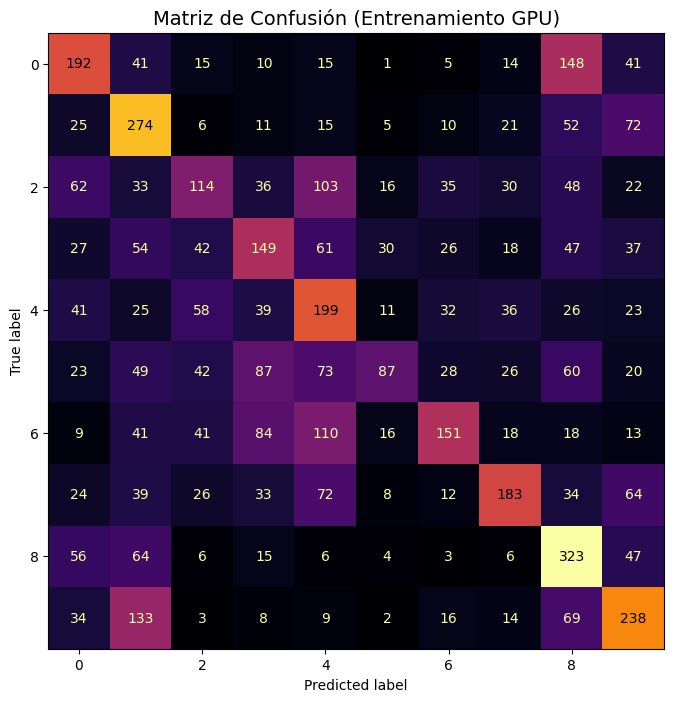

In [16]:
# === Celda 12.4: Matriz de Confusión (GPU) ===

print(f"-> Preparando datos de prueba en {dispositivo_exp2}...")
# Creamos un nuevo dataset/loader de prueba en GPU para este experimento
datos_test_gpu_exp1 = DatasetPrecargadoGPU(datos_test_cpu, dispositivo_gpu=dispositivo_exp2)
cargador_test_gpu_exp1 = DataLoader(datos_test_gpu_exp1, batch_size=CFG_LOTE_SIZE, shuffle=False)

lista_preds_gpu = []
lista_reales_gpu = []

with torch.no_grad():
  for imagenes_lote_test, etiquetas_lote_test in cargador_test_gpu_exp1:
    lista_reales_gpu.append(etiquetas_lote_test)
    lista_preds_gpu.append(red_gpu(imagenes_lote_test).detach().cpu())

etiquetas_reales_tensor_gpu = torch.cat(lista_reales_gpu).cpu()
predicciones_tensor_gpu = torch.argmax(torch.cat(lista_preds_gpu), dim=-1)

print(f"-> Predicciones (GPU) generadas. Forma: {predicciones_tensor_gpu.shape}")
matriz_conf_gpu = confusion_matrix(etiquetas_reales_tensor_gpu, predicciones_tensor_gpu)

# --- Visualización de la Matriz ---
print("--- Visualización: Matriz de Confusión (GPU) ---")
fig, ax = plt.subplots(figsize=(8, 8))
disp_gpu = ConfusionMatrixDisplay(matriz_conf_gpu, display_labels=[str(i) for i in range(10)])

disp_gpu.plot(cmap='inferno', ax=ax, colorbar=False)
ticks_personalizados = np.arange(0, 10, 2)
ax.set_xticks(ticks_personalizados)
ax.set_yticks(ticks_personalizados)
ax.set_xticklabels(ticks_personalizados)
ax.set_yticklabels(ticks_personalizados)
ax.set_title("Matriz de Confusión (Entrenamiento GPU)", fontsize=14)
ax.grid(False)
plt.show()

## 5. Experimento 2: Modelo Final Optimizado (GPU + Early Stopping)

Ahora que hemos comprobado la eficiencia de la GPU, entrenamos el modelo final.
Usamos:
* Los datos precargados en GPU.
* Hiperparámetros ajustados (LR más bajo, más épocas).
* La función `ejecutar_ciclo_entrenamiento` **con** el `MonitorPaciencia` para evitar el sobreajuste.

In [17]:
# --- Configuración del Experimento Final ---
CFG_FINAL_LOTE = 256
CFG_FINAL_LR = 1e-4 # Learning rate más bajo
CFG_FINAL_EPOCAS = 100 # Máximo (se detendrá antes)
CFG_FINAL_FREC_VAL = 5
CFG_FINAL_PACIENCIA = 6
CFG_FINAL_DELTA = 0.01

dispositivo_final = 'cuda'

# --- Modelo Final ---
red_final = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(dimension_entrada, neuronas_ocultas), # 128 neuronas
    torch.nn.Linear(neuronas_ocultas, neuronas_salida)
).to(dispositivo_final)

# --- DataLoaders Finales (reutilizamos los datasets precargados en GPU) ---
cargador_train_final = DataLoader(datos_ent_gpu, batch_size=CFG_FINAL_LOTE, shuffle=True)
cargador_val_final = DataLoader(datos_val_gpu, batch_size=CFG_FINAL_LOTE, shuffle=True)

# Instanciamos el monitor
monitor_entrenamiento = MonitorPaciencia(max_paciencia = CFG_FINAL_PACIENCIA,
                                       diferencia_minima = CFG_FINAL_DELTA)

print(f"||| INICIO EXPERIMENTO FINAL: GPU + Early Stopping |||")
print(f"    Total de Parámetros: {torch.tensor([p.numel() for p in red_final.parameters()]).sum()}")

# Ejecutamos el bucle de entrenamiento MONITOREADO
red_final, hist_loss_ent_final, hist_loss_val_final, hist_acc_val_final = ejecutar_ciclo_entrenamiento(
    cargador_train_final,
    cargador_val_final,
    red_final,
    CFG_FINAL_EPOCAS,
    funcion_costo,
    CFG_FINAL_LR,
    clase_optimizador,
    frecuencia_val = CFG_FINAL_FREC_VAL,
    monitor = monitor_entrenamiento)

print(f"\n*** Entrenamiento Finalizado. ***")


||| INICIO EXPERIMENTO FINAL: GPU + Early Stopping |||
    Total de Parámetros: 394634


Época:  55%|█████▌    | 55/100 [00:38<00:31,  1.44it/s, loss_train=1.6570]


[ALERTA] Detención Temprana. No hay mejora en 6 épocas.
-> Entrenamiento detenido por MonitorPaciencia.

*** Entrenamiento Finalizado. ***


### 5.1. Gráficas de Resultados (Modelo Final)

Visualizamos las curvas de pérdida y precisión del modelo final.

--- Visualización: Curvas de Aprendizaje (Modelo Final) ---


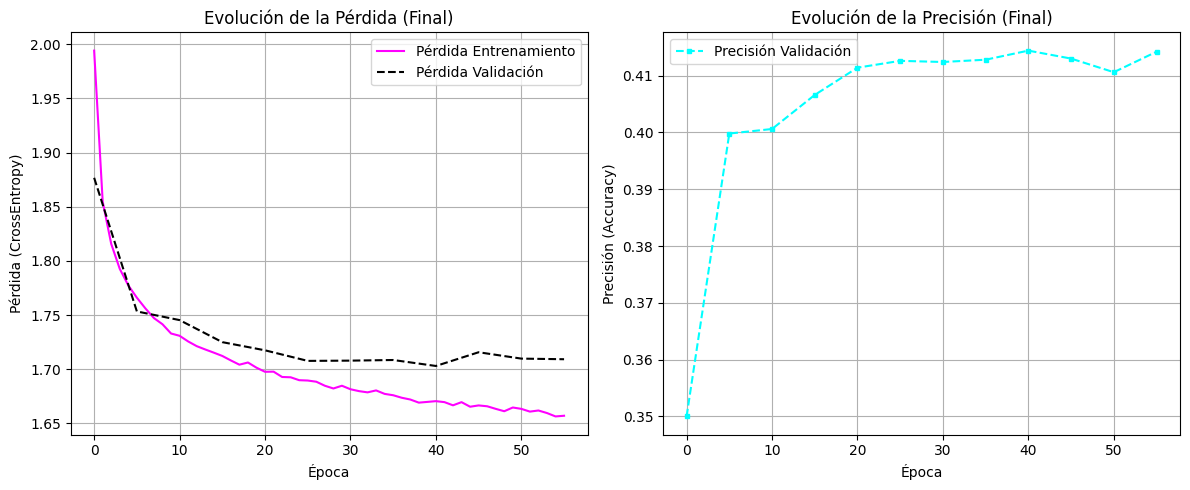

In [18]:
print("--- Visualización: Curvas de Aprendizaje (Modelo Final) ---")
plt.figure(figsize=(12, 5))

# --- Gráfico de Pérdida ---
plt.subplot(1, 2, 1)
plt.plot(hist_loss_ent_final, label="Pérdida Entrenamiento", color="magenta")
eje_x_val_final = range(0, CFG_FINAL_FREC_VAL * len(hist_loss_val_final), CFG_FINAL_FREC_VAL)
plt.plot(eje_x_val_final, hist_loss_val_final, label="Pérdida Validación", color="black", linestyle="--")
plt.title("Evolución de la Pérdida (Final)")
plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.legend()
plt.grid(True)

# --- Gráfico de Precisión ---
plt.subplot(1, 2, 2)
plt.plot(eje_x_val_final, hist_acc_val_final, label="Precisión Validación", color="cyan", marker="s", markersize=3, linestyle="--")
plt.title("Evolución de la Precisión (Final)")
plt.xlabel("Época")
plt.ylabel("Precisión (Accuracy)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### 5.2. Evaluación Final y Matriz de Confusión

Evaluamos el `red_final` contra el conjunto de prueba (`datos_test_cpu`) que habíamos reservado y que el modelo nunca ha visto.

-> Preparando datos de prueba en cuda para la evaluación final...
+++ PRECARGANDO 5000 elementos en cuda +++


100%|██████████| 5000/5000 [00:00<00:00, 7683.91it/s]


+++ Precarga en cuda completada. +++
-> Predicciones (Final) generadas. Forma: torch.Size([5000])
--- Visualización: Matriz de Confusión (Modelo Final) ---


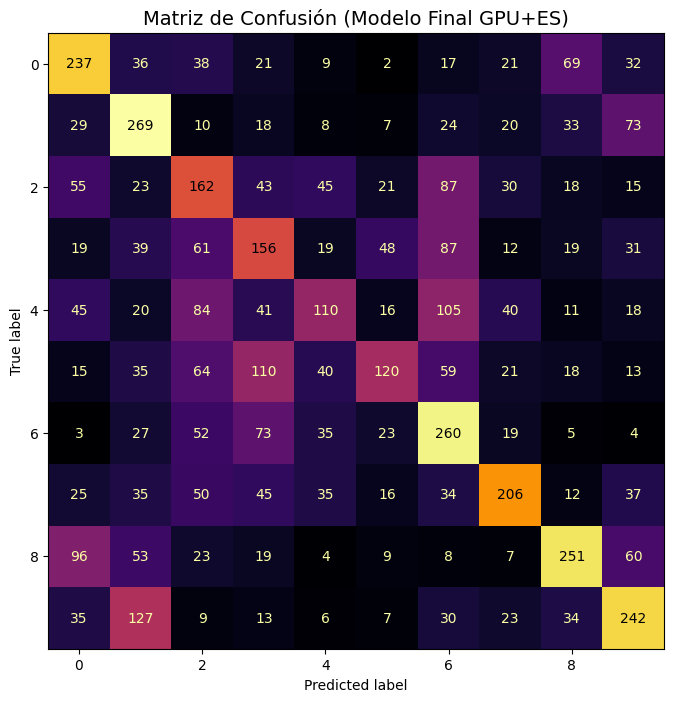

In [19]:
# --- Matriz de Confusión (Modelo Final) ---

print(f"-> Preparando datos de prueba en {dispositivo_final} para la evaluación final...")
# Precargamos el conjunto de prueba en la GPU
datos_test_gpu = DatasetPrecargadoGPU(datos_test_cpu, dispositivo_gpu=dispositivo_final)
cargador_test_final = DataLoader(datos_test_gpu, batch_size=CFG_FINAL_LOTE, shuffle=False)

lista_preds_final = []
lista_reales_final = []

with torch.no_grad():
  for imagenes_lote_test, etiquetas_lote_test in cargador_test_final:
    # Datos ya en GPU
    lista_reales_final.append(etiquetas_lote_test)
    # Predicción en GPU, resultado a CPU
    lista_preds_final.append(red_final(imagenes_lote_test).detach().cpu())

# Concatenamos en CPU
etiquetas_reales_tensor_final = torch.cat(lista_reales_final).cpu()
predicciones_tensor_final = torch.argmax(torch.cat(lista_preds_final), dim=-1)

print(f"-> Predicciones (Final) generadas. Forma: {predicciones_tensor_final.shape}")

# Calculamos la matriz de confusión final
matriz_conf_final = confusion_matrix(etiquetas_reales_tensor_final, predicciones_tensor_final)

# --- Visualización de la Matriz ---
print("--- Visualización: Matriz de Confusión (Modelo Final) ---")
fig, ax = plt.subplots(figsize=(8, 8))
etiquetas_clases = [str(i) for i in range(10)]
disp_final = ConfusionMatrixDisplay(matriz_conf_final, display_labels=etiquetas_clases)

# Usamos cmap 'inferno' y quitamos la barra de color
disp_final.plot(cmap='inferno', ax=ax, colorbar=False)

# Ponemos los ticks para que sean menos densos (cada 2 clases)
ticks_personalizados = np.arange(0, 10, 2)
ax.set_xticks(ticks_personalizados)
ax.set_yticks(ticks_personalizados)
ax.set_xticklabels(ticks_personalizados)
ax.set_yticklabels(ticks_personalizados)

ax.set_title("Matriz de Confusión (Modelo Final GPU+ES)", fontsize=14)
ax.grid(False)
plt.show()


## 6. Conclusión de la Comparativa de Tiempos

Finalmente, mostramos los resultados del Experimento 1.

In [20]:
print("=" * 50)
print(f"     COMPARATIVA DE TIEMPOS (CPU vs GPU Eficiente)")
print(f"     (Test realizado sobre {EPOCAS_TEST_VELOCIDAD} épocas)")
print("=" * 50)
print(f"| Dispositivo | Tiempo Total (seg) |")
print(f"|---------------|----------------------|")
print(f"| CPU           | {tiempo_cpu:>20.2f} |")
print(f"| GPU           | {tiempo_gpu:>20.2f} |")
print("=" * 50)
print(f"\nFACTOR DE ACELERACIÓN (GPU): {tiempo_cpu / tiempo_gpu:.2f}x más rápido")
print("=" * 50)


     COMPARATIVA DE TIEMPOS (CPU vs GPU Eficiente)
     (Test realizado sobre 20 épocas)
| Dispositivo | Tiempo Total (seg) |
|---------------|----------------------|
| CPU           |               175.03 |
| GPU           |                11.75 |

FACTOR DE ACELERACIÓN (GPU): 14.89x más rápido
